In [1]:
# Setup — install only on Colab; local execution uses the repository .venv.
# (Localmente necesitas: pip install ultralytics==8.4.102 matplotlib numpy torch)
import sys
if "google.colab" in sys.modules:
    %pip install -q ultralytics==8.4.102 matplotlib numpy torch

import torch
torch.manual_seed(0)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 580.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00


In [2]:
# Independent Colab assets — this notebook never reads another session's files.
from pathlib import Path
import os

SESSION_WORKSPACE = (Path("/content/yolo_object_detection_session_02") if "google.colab" in sys.modules
                     else Path.home() / "coco128_workspace" / "session_02")
SESSION_WORKSPACE.mkdir(parents=True, exist_ok=True)
os.chdir(SESSION_WORKSPACE)

from ultralytics import YOLO, settings
from ultralytics.data.utils import check_det_dataset

SESSION_DATASETS = SESSION_WORKSPACE / "datasets"
settings.update({"datasets_dir": str(SESSION_DATASETS)})
COCO128_INFO = check_det_dataset("coco128.yaml", autodownload=True)
COCO128_YAML = Path(COCO128_INFO.get("yaml_file", "coco128.yaml"))
BASELINE_MODEL = YOLO("yolo11n.pt")  # Downloads and caches this notebook's pretrained weights.
print(f"Colab-only session 2: workspace={SESSION_WORKSPACE} | dataset={COCO128_YAML} | model=yolo11n.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/content/yolo_object_detection_session_02/datasets/coco128/images/train2017'
Unzipping /content/yolo_object_detection_session_02/datasets/coco128.zip to /content/yolo_object_detection_session_02/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 4.4Kfiles/s 0.1s
Dataset download success ✅ (1.0s), saved to /content/yolo_object_detection_session_02/datasets

Colab-only session 2: workspace=/content/yolo_object_detection_session_02 | dataset=/usr/local/lib/python3.13/dist-packages/ultralytics/cfg/datasets/coco128.yaml | model=yolo11n.pt


In [3]:
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import numpy as np
import torch

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
IN_COLAB = "google.colab" in sys.modules
RUN_REAL_MODEL = IN_COLAB  # Colab provisions COCO128 and yolo11n.pt automatically.
print(f"numpy={np.__version__} | torch={torch.__version__} | Colab={IN_COLAB}")

numpy=2.1.3 | torch=2.11.0+cpu | Colab=True


## 1. Work the IoU example

Use half-open corner coordinates `(x1, y1, x2, y2)`: the right and bottom edges are excluded, so width is `x2 - x1` without `+1`. Let $A=(1,1,5,4)$ and $B=(3,2,7,6)$.

In [4]:
A = np.array([1.0, 1.0, 5.0, 4.0])
B = np.array([3.0, 2.0, 7.0, 6.0])
area_A = (A[2] - A[0]) * (A[3] - A[1])
area_B = (B[2] - B[0]) * (B[3] - B[1])
intersection_wh = np.maximum(0.0, np.minimum(A[2:], B[2:]) - np.maximum(A[:2], B[:2]))
intersection = intersection_wh.prod()
union = area_A + area_B - intersection
worked_iou = intersection / union
print(f"areas: A={area_A:g}, B={area_B:g}")
print(f"intersection={intersection:g}, union={union:g}, IoU={worked_iou:.6f}")
assert np.isclose(worked_iou, 1 / 6)

areas: A=12, B=16
intersection=4, union=24, IoU=0.166667


The clamp in `maximum(0, ...)` matters: disjoint boxes otherwise produce a negative width or height. Union uses inclusion–exclusion, so the overlap is subtracted once.

### Exercise E1 — implement vector-safe IoU

Implement `box_iou_xyxy(a, b)`. Accept shape `(4,)` or arrays whose last dimension is 4, use NumPy broadcasting, and raise `ValueError` when a box has non-positive width or height.

In [5]:
# TODO: Implement box_iou_xyxy(a, b) for arrays ending in four xyxy coordinates.
# HINT: Clamp only intersection widths/heights; reject malformed input boxes.


In [6]:
# 🟩 RESPUESTA (JRSA)
def box_iou_xyxy(a, b):
    """Vectorized IoU between boxes in half-open xyxy corner format.
    Accepts shape (4,) or arrays whose last dimension is 4; broadcasts like NumPy.
    Raises ValueError if any box has non-positive width or height."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    for arr in (a, b):
        widths = arr[..., 2] - arr[..., 0]
        heights = arr[..., 3] - arr[..., 1]
        if np.any(widths <= 0) or np.any(heights <= 0):
            raise ValueError("box has non-positive width or height")

    area_a = (a[..., 2] - a[..., 0]) * (a[..., 3] - a[..., 1])
    area_b = (b[..., 2] - b[..., 0]) * (b[..., 3] - b[..., 1])

    inter_x1 = np.maximum(a[..., 0], b[..., 0])
    inter_y1 = np.maximum(a[..., 1], b[..., 1])
    inter_x2 = np.minimum(a[..., 2], b[..., 2])
    inter_y2 = np.minimum(a[..., 3], b[..., 3])

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    intersection = inter_w * inter_h

    union = area_a + area_b - intersection
    return intersection / union


Test the normal case plus identical, disjoint, touching-edge, and partially overlapping boxes. The paired arrays in the final assertion also check vector behavior.

In [7]:
edge_cases = {
    "worked 1/6": (A, B, 1 / 6),
    "identical": ([0, 0, 2, 2], [0, 0, 2, 2], 1.0),
    "disjoint": ([0, 0, 1, 1], [2, 2, 3, 3], 0.0),
    "touching edge": ([0, 0, 1, 1], [1, 0, 2, 1], 0.0),
    "partial overlap": ([0, 0, 2, 2], [1, 1, 3, 3], 1 / 7),
}
for name, (left, right, expected) in edge_cases.items():
    actual = box_iou_xyxy(left, right)
    print(f"{name:16s}: {actual:.6f}")
    assert np.isfinite(actual) and 0 <= actual <= 1 and np.isclose(actual, expected)

paired = box_iou_xyxy(np.array([[0, 0, 2, 2], [0, 0, 1, 1]]),
                         np.array([[0, 0, 2, 2], [1, 0, 2, 1]]))
assert np.allclose(paired, [1.0, 0.0]) and paired.shape == (2,)
try:
    box_iou_xyxy([2, 0, 1, 1], [0, 0, 1, 1])
except ValueError as error:
    print("malformed box rejected:", error)
else:
    raise AssertionError("A malformed box should raise ValueError.")

worked 1/6      : 0.166667
identical       : 1.000000
disjoint        : 0.000000
touching edge   : 0.000000
partial overlap : 0.142857
malformed box rejected: box has non-positive width or height


## 2. Compare three detection pipelines

- **Sliding windows:** run a classifier on many crops, scales, and aspect ratios.
- **Proposal-based detector:** shortlist likely regions, then classify/refine them while sharing more computation.
- **One-stage detector:** compute image-wide features once, then use shared heads at many feature locations to emit candidates.

One stage means one shared prediction pipeline—not one layer, one candidate, or one final box.

## 3. Inspect stable result fields

Inspect the documented public fields from the real predictions: image shape plus `boxes.xyxy`, `boxes.conf`, and `boxes.cls`. Avoid relying on undocumented raw-head layouts.

The next cell selects real COCO128 images from this notebook's downloaded dataset and runs the pinned pretrained model.


In [8]:
# Run real inference on this notebook's independently downloaded COCO128 copy.
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}
train_root = Path(COCO128_INFO["train"])
candidate_paths = sorted(path for path in train_root.rglob("*") if path.suffix.lower() in IMAGE_SUFFIXES)[:12]
if len(candidate_paths) < 3:
    raise RuntimeError(f"Expected at least 3 COCO128 images under {train_root}.")

candidate_results = BASELINE_MODEL.predict([str(path) for path in candidate_paths], conf=0.25, iou=0.70, verbose=False)
usable = [(path, result) for path, result in zip(candidate_paths, candidate_results) if len(result.boxes) > 0]
selected_pairs = (usable + [(path, result) for path, result in zip(candidate_paths, candidate_results) if len(result.boxes) == 0])[:3]
if len(selected_pairs) < 3:
    raise RuntimeError("YOLO did not return three COCO128 results.")

image_paths = [path for path, _ in selected_pairs]
real_results = [result for _, result in selected_pairs]
print(f"model=yolo11n.pt | selected real COCO128 images: {[path.name for path in image_paths]}")
print("final boxes per image:", [len(result.boxes) for result in real_results])


model=yolo11n.pt | selected real COCO128 images: ['000000000009.jpg', '000000000025.jpg', '000000000030.jpg']
final boxes per image: [5, 1, 2]


Inspect shapes and fields through the same public interface in either mode. Avoid undocumented raw-head tensor layouts: they can change between YOLO versions.

In [9]:
# Inspect only documented public result fields from real Ultralytics predictions.
results = real_results

def to_numpy(value):
    if hasattr(value, "detach"):
        return value.detach().cpu().numpy()
    return np.asarray(value)

summaries = []
for image_path, result in zip(image_paths, results):
    xyxy = to_numpy(result.boxes.xyxy)
    conf = to_numpy(result.boxes.conf)
    class_ids = to_numpy(result.boxes.cls).astype(int)
    class_names = [result.names[int(class_id)] for class_id in class_ids]
    summaries.append((image_path.name, result.orig_shape, len(result.boxes), xyxy.shape, class_names, conf.round(3).tolist()))

for label, image_shape, count, box_shape, classes, confidences in summaries:
    print(f"{label:18s} image={image_shape} | detections={count} | xyxy={box_shape}")
    print(f"{'':18s} classes={classes} | confidence={confidences}")
assert len(results) == 3, "Expected three real COCO128 result objects."


000000000009.jpg   image=(480, 640) | detections=5 | xyxy=(5, 4)
                   classes=['bowl', 'broccoli', 'bowl', 'bowl', 'broccoli'] | confidence=[0.9290000200271606, 0.8410000205039978, 0.777999997138977, 0.6169999837875366, 0.37400001287460327]
000000000025.jpg   image=(426, 640) | detections=1 | xyxy=(1, 4)
                   classes=['giraffe'] | confidence=[0.8769999742507935]
000000000030.jpg   image=(428, 640) | detections=2 | xyxy=(2, 4)
                   classes=['vase', 'potted plant'] | confidence=[0.9079999923706055, 0.6439999938011169]


## 4. View real detections and their boxes

The first figure is the model's annotated output on three real COCO128 images. The second is a box-coordinate plot of exactly the same final detections. The third overlays green ground-truth boxes from COCO128 labels with orange dashed YOLO predictions on the original images.


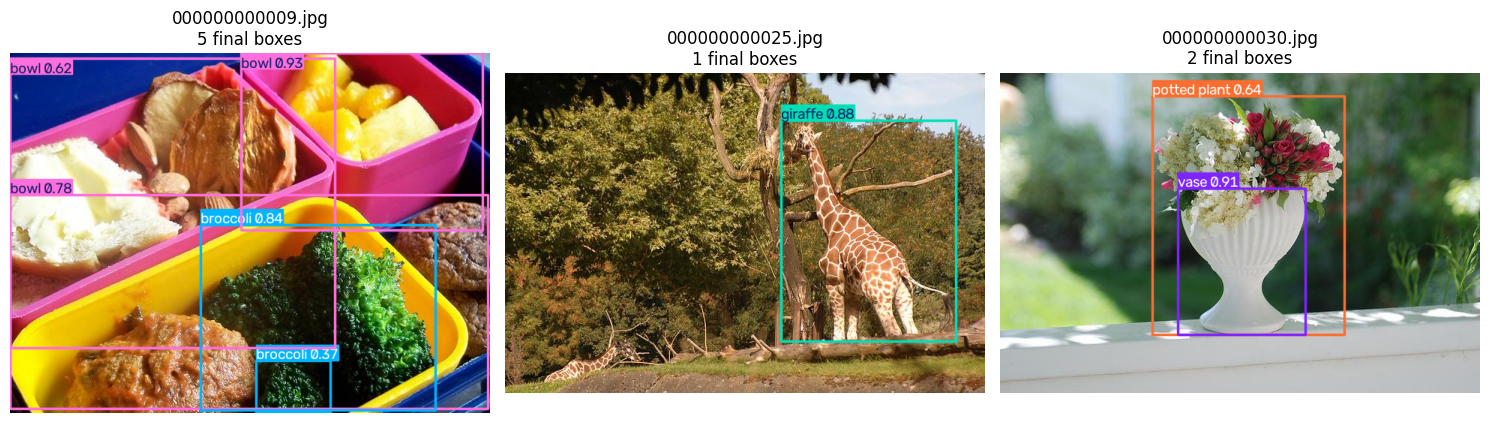

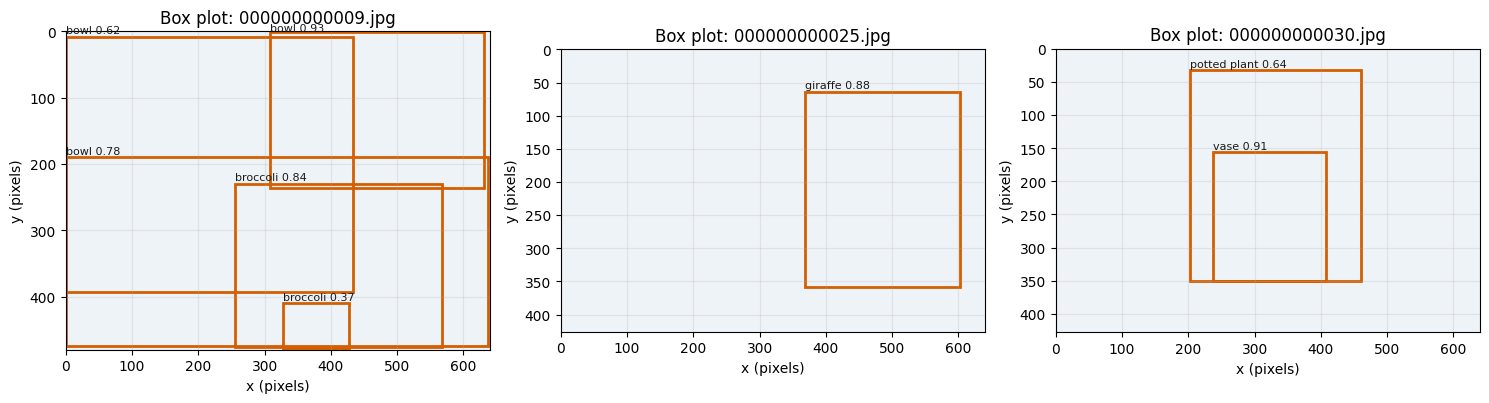

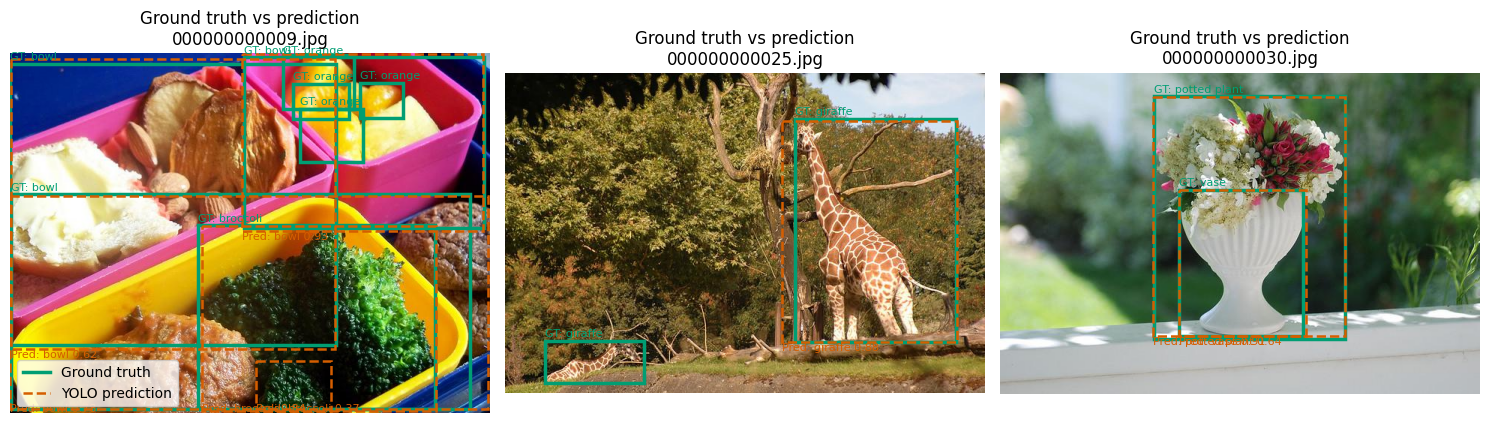

In [10]:
# Real annotated images: Ultralytics renders the same final boxes, labels, and confidences.
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
axes = np.atleast_1d(axes)
for axis, image_path, result in zip(axes, image_paths, results):
    axis.imshow(result.plot()[..., ::-1])  # Ultralytics plot is BGR; Matplotlib expects RGB.
    axis.set_title(f"{image_path.name}\n{len(result.boxes)} final boxes")
    axis.axis("off")
plt.tight_layout()
plt.show()

# Box plot: draw those same real xyxy boxes on a coordinate plane.
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
axes = np.atleast_1d(axes)
for axis, image_path, result in zip(axes, image_paths, results):
    height, width = result.orig_shape
    axis.set_xlim(0, width)
    axis.set_ylim(height, 0)
    axis.set_aspect("equal")
    axis.set_facecolor("#eef3f7")
    xyxy = to_numpy(result.boxes.xyxy)
    confidence = to_numpy(result.boxes.conf)
    class_ids = to_numpy(result.boxes.cls).astype(int)
    for box, score, class_id in zip(xyxy, confidence, class_ids):
        x1, y1, x2, y2 = box
        axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="#d55e00", linewidth=2))
        axis.text(x1, max(0, y1 - 5), f"{result.names[int(class_id)]} {score:.2f}", fontsize=8, color="#1b1b1b")
    axis.set_title(f"Box plot: {image_path.name}")
    axis.set_xlabel("x (pixels)")
    axis.set_ylabel("y (pixels)")
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Ground truth (green) versus real YOLO predictions (orange) on the same images.
COCO_ROOT = Path(COCO128_INFO["path"])
COCO_NAMES = COCO128_INFO["names"]
if isinstance(COCO_NAMES, list):
    COCO_NAMES = dict(enumerate(COCO_NAMES))

def yolo_ground_truth_xyxy(image_path, image_height, image_width):
    relative_image = image_path.relative_to(COCO_ROOT / "images")
    label_path = (COCO_ROOT / "labels" / relative_image).with_suffix(".txt")
    rows = [] if not label_path.exists() else label_path.read_text(encoding="utf-8").splitlines()
    boxes = []
    for row in rows:
        class_id, x_center, y_center, box_width, box_height = map(float, row.split())
        x_center, box_width = x_center * image_width, box_width * image_width
        y_center, box_height = y_center * image_height, box_height * image_height
        boxes.append((int(class_id), x_center - box_width / 2, y_center - box_height / 2,
                      x_center + box_width / 2, y_center + box_height / 2))
    return boxes

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
axes = np.atleast_1d(axes)
for axis, image_path, result in zip(axes, image_paths, results):
    image = plt.imread(image_path)
    height, width = result.orig_shape
    axis.imshow(image)
    for class_id, x1, y1, x2, y2 in yolo_ground_truth_xyxy(image_path, height, width):
        axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="#009e73", linewidth=2.5))
        axis.text(x1, max(0, y1 - 5), f"GT: {COCO_NAMES[class_id]}", color="#009e73", fontsize=8)
    for box, score, class_id in zip(to_numpy(result.boxes.xyxy), to_numpy(result.boxes.conf),
                                    to_numpy(result.boxes.cls).astype(int)):
        x1, y1, x2, y2 = box
        axis.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="#d55e00", linewidth=1.8, linestyle="--"))
        axis.text(x1, min(height - 2, y2 + 12), f"Pred: {result.names[class_id]} {score:.2f}", color="#d55e00", fontsize=8)
    axis.set_title(f"Ground truth vs prediction\n{image_path.name}")
    axis.axis("off")
axes[0].legend(handles=[
    Line2D([0], [0], color="#009e73", linewidth=2.5, label="Ground truth"),
    Line2D([0], [0], color="#d55e00", linewidth=1.8, linestyle="--", label="YOLO prediction"),
], loc="lower left")
plt.tight_layout()
plt.show()


### Per-prediction IoU report

For each predicted box, print the highest-IoU ground-truth box **of the same class**. This is a diagnostic nearest-match report, not the one-to-one assignment used to compute AP: multiple predictions may name the same ground-truth box here.


In [11]:
# Print the best same-class ground-truth IoU for every real predicted box.
for image_path, result in zip(image_paths, results):
    height, width = result.orig_shape
    ground_truth = yolo_ground_truth_xyxy(image_path, height, width)
    print(f"\n{image_path.name}")
    prediction_boxes = to_numpy(result.boxes.xyxy)
    prediction_confidence = to_numpy(result.boxes.conf)
    prediction_classes = to_numpy(result.boxes.cls).astype(int)
    for prediction_index, (prediction_box, confidence, class_id) in enumerate(
        zip(prediction_boxes, prediction_confidence, prediction_classes), start=1
    ):
        same_class_truth = [box for gt_class, *box in ground_truth if gt_class == class_id]
        class_name = result.names[class_id]
        if not same_class_truth:
            print(f"  pred {prediction_index:02d} | {class_name:15s} conf={confidence:.3f} | no same-class ground truth")
            continue
        ious = box_iou_xyxy(prediction_box, np.asarray(same_class_truth, dtype=float))
        best_index = int(np.argmax(ious))
        print(
            f"  pred {prediction_index:02d} | {class_name:15s} conf={confidence:.3f} "
            f"| best same-class GT={best_index + 1} | IoU={float(ious[best_index]):.3f}"
        )



000000000009.jpg
  pred 01 | bowl            conf=0.929 | best same-class GT=2 | IoU=0.958
  pred 02 | broccoli        conf=0.841 | best same-class GT=1 | IoU=0.970
  pred 03 | bowl            conf=0.778 | best same-class GT=1 | IoU=0.951
  pred 04 | bowl            conf=0.617 | best same-class GT=3 | IoU=0.967
  pred 05 | broccoli        conf=0.374 | best same-class GT=1 | IoU=0.082

000000000025.jpg
  pred 01 | giraffe         conf=0.877 | best same-class GT=1 | IoU=0.909

000000000030.jpg
  pred 01 | vase            conf=0.908 | best same-class GT=1 | IoU=0.973
  pred 02 | potted plant    conf=0.644 | best same-class GT=1 | IoU=0.975
